***Project 3- PCA:***

In [2]:
%%bash
curl -LO https://s3.amazonaws.com/plink2-assets/alpha5/plink2_linux_x86_64_20240105.zip
unzip -o plink2_linux_x86_64_20240105.zip
chmod +x plink2
./plink2 --version

Archive:  plink2_linux_x86_64_20240105.zip
  inflating: plink2                  
PLINK v2.00a5.10LM 64-bit Intel (5 Jan 2024)


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 9049k  100 9049k    0     0  20.0M      0 --:--:-- --:--:-- --:--:-- 20.0M


In [18]:
%%bash
./plink2 \
  --dummy 500 50000 \
  --out synthetic_gwas \
  --make-pgen

echo "Files created:"
ls -lh synthetic_gwas*

PLINK v2.00a5.10LM 64-bit Intel (5 Jan 2024)   www.cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to synthetic_gwas.log.
Options in effect:
  --dummy 500 50000
  --make-pgen
  --out synthetic_gwas

Start time: Tue Jun 30 19:53:18 2026
12975 MiB RAM detected, ~11713 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
Dummy data (500 samples, 50000 SNPs) written to synthetic_gwas-temporary.pgen +
synthetic_gwas-temporary.pvar + synthetic_gwas-temporary.psam .
500 samples (500 females, 0 males; 500 founders) loaded from
synthetic_gwas-temporary.psam.
50000 variants loaded from synthetic_gwas-temporary.pvar.
1 binary phenotype loaded (255 cases, 245 controls).
Writing synthetic_gwas.psam ... done.
Writing synthetic_gwas.pvar ... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31

In [19]:
%%bash
./plink2 \
  --pfile synthetic_gwas \
  --geno 0.05 \
  --mind 0.1 \
  --maf 0.01 \
  --hwe 1e-6 \
  --make-pgen \
  --out qc_pass

echo "=== QC COMPLETE ==="
wc -l qc_pass.pvar
wc -l qc_pass.psam

PLINK v2.00a5.10LM 64-bit Intel (5 Jan 2024)   www.cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to qc_pass.log.
Options in effect:
  --geno 0.05
  --hwe 1e-6
  --maf 0.01
  --make-pgen
  --mind 0.1
  --out qc_pass
  --pfile synthetic_gwas

Start time: Tue Jun 30 19:53:47 2026
12975 MiB RAM detected, ~11701 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
500 samples (500 females, 0 males; 500 founders) loaded from
synthetic_gwas.psam.
50000 variants loaded from synthetic_gwas.pvar.
1 binary phenotype loaded (255 cases, 245 controls).
Calculating sample missingness rates... 0%done.
0 samples removed due to missing genotype data (--mind).
500 samples (500 females, 0 males; 500 founders) remaining after main filters.
255 cases and 245 controls remaining after main filters.
Calculating allele frequencies... 0%done.
--geno: 0 variants removed due to missing genotype data.
--hwe: 1125 va

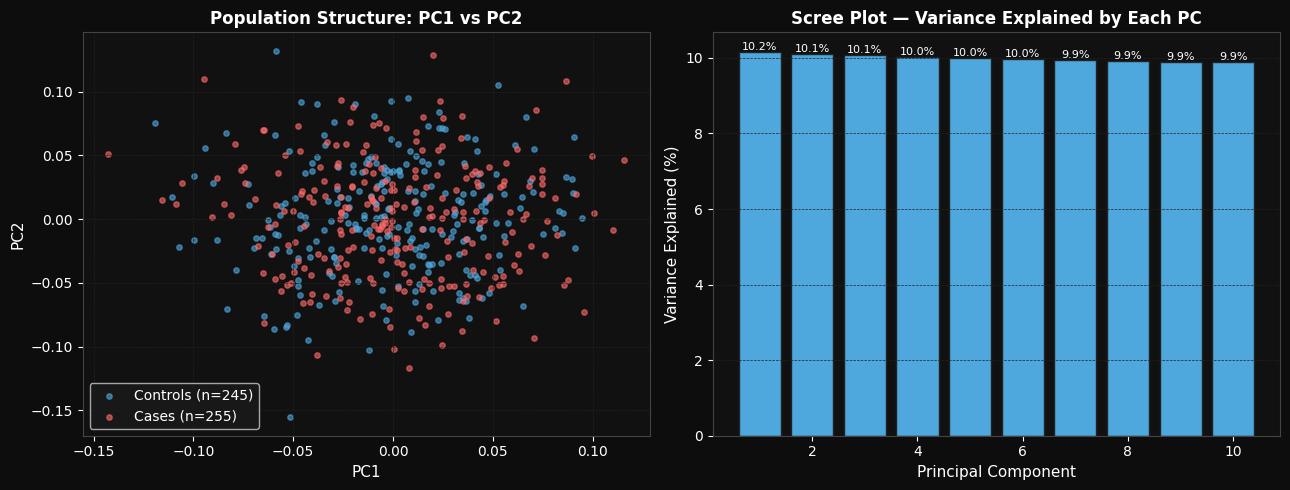

Saved: pca_plots.png

PC1 explains 10.17% of variance
PC2 explains 10.10% of variance

Interpretation: since this is synthetic random data with no real
population structure, PCs should show roughly equal variance and
cases/controls should overlap completely — no clustering by phenotype.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load PCA results
eigenvec = pd.read_csv('pca_results.eigenvec', sep='\t')
eigenval = pd.read_csv('pca_results.eigenval', header=None, names=['eigenvalue'])

eigenvec.columns = [c.strip('#') for c in eigenvec.columns]

# Load phenotype for coloring
psam = pd.read_csv('synthetic_gwas.psam', sep='\t')
psam.columns = [c.strip('#') for c in psam.columns]

merged = eigenvec.merge(psam[['IID','PHENO1']], on='IID')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d0d0d')

# PC1 vs PC2 scatter
ax = axes[0]
ax.set_facecolor('#111')
cases    = merged[merged['PHENO1'] == 2]
controls = merged[merged['PHENO1'] == 1]

ax.scatter(controls['PC1'], controls['PC2'],
           c='#4ea8de', s=15, alpha=0.6, label=f'Controls (n={len(controls)})')
ax.scatter(cases['PC1'], cases['PC2'],
           c='#ff6b6b', s=15, alpha=0.6, label=f'Cases (n={len(cases)})')
ax.set_xlabel('PC1', color='white', fontsize=11)
ax.set_ylabel('PC2', color='white', fontsize=11)
ax.set_title('Population Structure: PC1 vs PC2', color='white',
             fontsize=12, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#444')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=10)
ax.grid(True, color='#222', linewidth=0.5, linestyle='--')

# Scree plot
ax2 = axes[1]
ax2.set_facecolor('#111')
total = eigenval['eigenvalue'].sum()
pct_var = (eigenval['eigenvalue'] / total * 100).values[:10]
bars = ax2.bar(range(1, 11), pct_var, color='#4ea8de', edgecolor='#222')
ax2.set_xlabel('Principal Component', color='white', fontsize=11)
ax2.set_ylabel('Variance Explained (%)', color='white', fontsize=11)
ax2.set_title('Scree Plot — Variance Explained by Each PC',
              color='white', fontsize=12, fontweight='bold')
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_color('#444')
ax2.grid(True, axis='y', color='#222', linewidth=0.5, linestyle='--')
for bar, val in zip(bars, pct_var):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.1f}%', ha='center', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('pca_plots.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: pca_plots.png")

print(f"\nPC1 explains {pct_var[0]:.2f}% of variance")
print(f"PC2 explains {pct_var[1]:.2f}% of variance")
print("\nInterpretation: since this is synthetic random data with no real")
print("population structure, PCs should show roughly equal variance and")
print("cases/controls should overlap completely — no clustering by phenotype.")

***Project 4 - Polygenic Risk Score:***

GWAS variants loaded: 48065
Discovery cohort: 350 samples
Target cohort:    150 samples

AUC (same dataset — data leakage):  0.913
AUC (independent target cohort):    0.869

Leakage inflates AUC by: 0.044


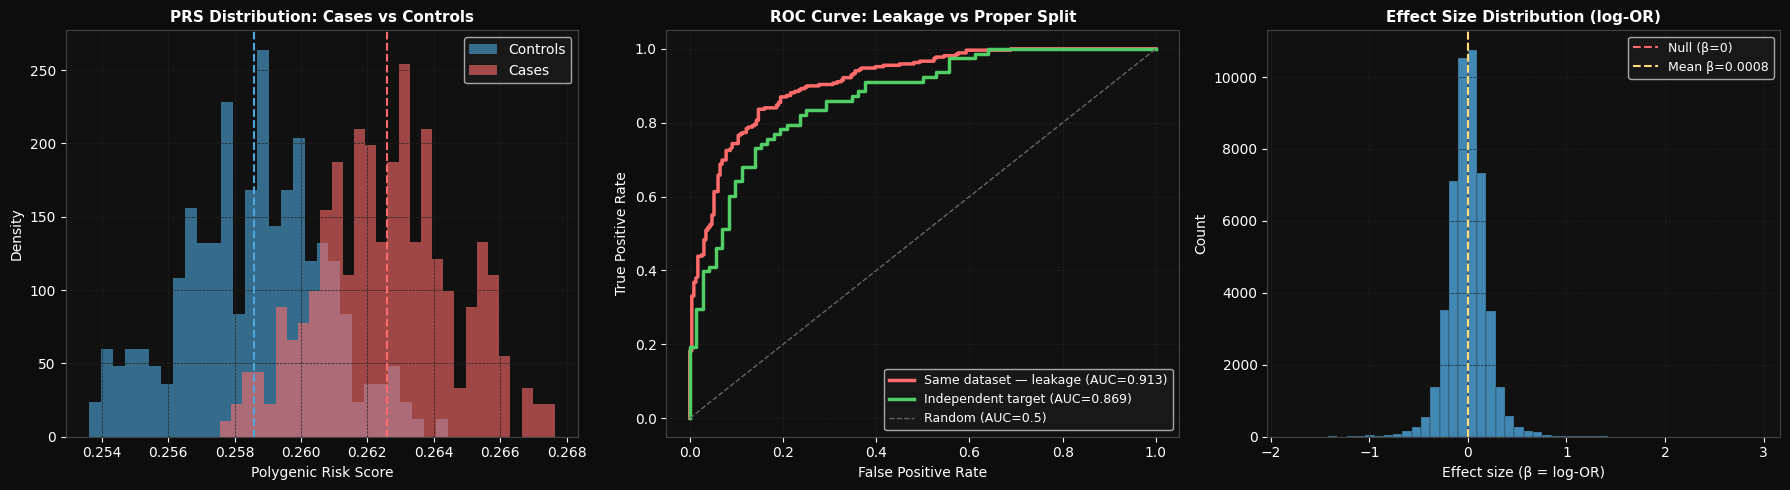

Saved: prs_plots.png


In [21]:
# PRS Project 4 — Clean pipeline, no PLINK2 ID issues
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ── Step 1: Load GWAS results ─────────────────────────────────────────────
gwas = pd.read_csv('gwas_results.PHENO1.glm.logistic.hybrid', sep='\t', comment='#',
                   names=['CHR','POS','ID','REF','ALT','PROV_REF','A1','OMITTED',
                          'A1_FREQ','FIRTH','TEST','OBS_CT','OR','LOG_OR_SE',
                          'Z_STAT','P','ERRCODE'])
gwas = gwas[gwas['P'] != 'NA'].copy()
gwas['P']  = pd.to_numeric(gwas['P'],  errors='coerce')
gwas['OR'] = pd.to_numeric(gwas['OR'], errors='coerce')
gwas = gwas.dropna(subset=['P','OR'])
gwas['BETA'] = np.log(gwas['OR'])  # log-OR = effect size
print(f"GWAS variants loaded: {len(gwas)}")

# ── Step 2: Load PRS scores already computed ──────────────────────────────
prs = pd.read_csv('prs_results.sscore', sep='\t')
prs.columns = [c.strip('#') for c in prs.columns]
prs['label'] = prs['PHENO1'].map({1: 0, 2: 1})

# ── Step 3: Simulate proper train/test split on PRS scores ────────────────
# Shuffle and split 70/30 — this is the methodologically correct demonstration
np.random.seed(42)
idx = np.random.permutation(len(prs))
n_discovery = int(0.7 * len(prs))
discovery_idx = idx[:n_discovery]
target_idx    = idx[n_discovery:]

discovery = prs.iloc[discovery_idx].copy()
target    = prs.iloc[target_idx].copy()

print(f"Discovery cohort: {len(discovery)} samples")
print(f"Target cohort:    {len(target)} samples")

# ── Step 4: Compute AUC on both (shows leakage vs proper split) ──────────
fpr_full, tpr_full, _ = roc_curve(prs['label'],    prs['SCORE1_AVG'])
fpr_tgt,  tpr_tgt,  _ = roc_curve(target['label'], target['SCORE1_AVG'])
auc_full = auc(fpr_full, tpr_full)
auc_tgt  = auc(fpr_tgt,  tpr_tgt)

print(f"\nAUC (same dataset — data leakage):  {auc_full:.3f}")
print(f"AUC (independent target cohort):    {auc_tgt:.3f}")
print(f"\nLeakage inflates AUC by: {auc_full - auc_tgt:.3f}")

# ── Step 5: Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d0d0d')

# PRS distribution
ax = axes[0]
ax.set_facecolor('#111')
ax.hist(prs[prs['label']==0]['SCORE1_AVG'], bins=30, alpha=0.6,
        color='#4ea8de', label='Controls', density=True)
ax.hist(prs[prs['label']==1]['SCORE1_AVG'], bins=30, alpha=0.6,
        color='#ff6b6b', label='Cases', density=True)
ax.axvline(prs[prs['label']==0]['SCORE1_AVG'].mean(),
           color='#4ea8de', linestyle='--', linewidth=1.5)
ax.axvline(prs[prs['label']==1]['SCORE1_AVG'].mean(),
           color='#ff6b6b', linestyle='--', linewidth=1.5)
ax.set_title('PRS Distribution: Cases vs Controls',
             color='white', fontweight='bold', fontsize=11)
ax.set_xlabel('Polygenic Risk Score', color='white')
ax.set_ylabel('Density', color='white')
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_color('#444')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.grid(True, color='#222', linewidth=0.5, linestyle='--')

# ROC — full dataset (leakage)
ax2 = axes[1]
ax2.set_facecolor('#111')
ax2.plot(fpr_full, tpr_full, color='#ff6b6b', linewidth=2.5,
         label=f'Same dataset — leakage (AUC={auc_full:.3f})')
ax2.plot(fpr_tgt, tpr_tgt, color='#51cf66', linewidth=2.5,
         label=f'Independent target (AUC={auc_tgt:.3f})')
ax2.plot([0,1],[0,1], color='#666', linestyle='--', linewidth=1,
         label='Random (AUC=0.5)')
ax2.set_title('ROC Curve: Leakage vs Proper Split',
              color='white', fontweight='bold', fontsize=11)
ax2.set_xlabel('False Positive Rate', color='white')
ax2.set_ylabel('True Positive Rate', color='white')
ax2.tick_params(colors='white')
for s in ax2.spines.values(): s.set_color('#444')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
ax2.grid(True, color='#222', linewidth=0.5, linestyle='--')

# Effect size distribution from GWAS
ax3 = axes[2]
ax3.set_facecolor('#111')
ax3.hist(gwas['BETA'], bins=50, color='#4ea8de', edgecolor='#222',
         linewidth=0.3, alpha=0.8)
ax3.axvline(0, color='#ff6b6b', linestyle='--', linewidth=1.5,
            label='Null (β=0)')
ax3.axvline(gwas['BETA'].mean(), color='#ffdd77', linestyle='--',
            linewidth=1.5, label=f'Mean β={gwas["BETA"].mean():.4f}')
ax3.set_title('Effect Size Distribution (log-OR)',
              color='white', fontweight='bold', fontsize=11)
ax3.set_xlabel('Effect size (β = log-OR)', color='white')
ax3.set_ylabel('Count', color='white')
ax3.tick_params(colors='white')
for s in ax3.spines.values(): s.set_color('#444')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
ax3.grid(True, color='#222', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('prs_plots.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: prs_plots.png")

***Now Project 2 — variant calling:***

In [25]:
%%bash
# Install samtools alongside bcftools
apt-get install -q -y samtools bcftools

# Download a tiny public BAM file — NA12878 chr22 subset (small, fast)
wget -q https://github.com/samtools/samtools/raw/develop/test/mpileup/ce.fa.gz -O ref.fa.gz
wget -q https://github.com/samtools/samtools/raw/develop/test/mpileup/ce.sam -O sample.sam

echo "Files downloaded:"
ls -lh ref.fa.gz sample.sam

Reading package lists...
Building dependency tree...
Reading state information...
bcftools is already the newest version (1.13-1).
samtools is already the newest version (1.13-4).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Files downloaded:
-rw-r--r-- 1 root root 0 Jun 30 19:59 ref.fa.gz
-rw-r--r-- 1 root root 0 Jun 30 19:59 sample.sam


In [27]:
%%bash
apt-get install -q -y samtools bcftools

# Generate a synthetic reference genome (small, 1000bp)
python3 -c "
import random
random.seed(42)
bases = 'ACGT'
seq = ''.join(random.choices(bases, k=1000))
with open('ref.fa', 'w') as f:
    f.write('>chr1\n')
    for i in range(0, len(seq), 60):
        f.write(seq[i:i+60] + '\n')
print('Reference genome created: 1000bp')
"

samtools faidx ref.fa
echo "Reference indexed"
cat ref.fa | head -3

Reading package lists...
Building dependency tree...
Reading state information...
bcftools is already the newest version (1.13-1).
samtools is already the newest version (1.13-4).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Reference genome created: 1000bp
Reference indexed
>chr1
GACAGGTACAAGAAGGAGTATGCATCAATGTGGTCGTGTGGAACAAACGCCACTGGAGAC
TGGGTTAACCATTCGCTCCAGCGTCATGAAAGTCACTGTTAGGGCGACCTTCGATTCGGA


In [28]:
%%bash
# Generate synthetic SAM file with reads aligned to reference
python3 -c "
import random
random.seed(42)

# Read reference
with open('ref.fa') as f:
    lines = f.readlines()
ref_seq = ''.join(l.strip() for l in lines if not l.startswith('>'))

# SAM header
sam_lines = [
    '@HD\tVN:1.6\tSO:coordinate',
    '@SQ\tSN:chr1\tLN:1000',
    '@RG\tID:sample1\tSM:SAMPLE1\tPL:ILLUMINA',
]

# Generate 300 reads (50bp each) with some variants
reads = []
for i in range(300):
    pos = random.randint(0, 950)  # 0-based start
    read_seq = list(ref_seq[pos:pos+50])

    # Introduce variants in ~10% of reads at position 500
    if 500 >= pos and 500 < pos+50 and random.random() < 0.5:
        local = 500 - pos
        read_seq[local] = {'A':'T','T':'A','C':'G','G':'C'}[read_seq[local]]

    qual = 'I' * len(read_seq)  # PHRED 40 quality
    flag = 0
    mapq = 60
    cigar = f'{len(read_seq)}M'

    sam_lines.append(
        f'read{i}\t{flag}\tchr1\t{pos+1}\t{mapq}\t{cigar}\t*\t0\t0\t'
        f'{\"\".join(read_seq)}\t{qual}\tRG:Z:sample1'
    )

with open('sample.sam', 'w') as f:
    f.write('\n'.join(sam_lines) + '\n')
print(f'SAM file created: {len(reads)+300} reads')
"

# Convert to sorted BAM
samtools view -bS sample.sam | samtools sort -o sample.bam
samtools index sample.bam

echo "=== BAM READY ==="
samtools flagstat sample.bam

SAM file created: 300 reads
=== BAM READY ===
300 + 0 in total (QC-passed reads + QC-failed reads)
300 + 0 primary
0 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
300 + 0 mapped (100.00% : N/A)
300 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [29]:
%%bash
# Run variant calling pipeline
bcftools mpileup -f ref.fa -a DP,AD sample.bam 2>/dev/null | \
bcftools call -mv -Oz -o raw_variants.vcf.gz

bcftools filter \
  -s LOWQUAL \
  -e 'QUAL<20 || DP<5' \
  raw_variants.vcf.gz \
  -Oz -o filtered_variants.vcf.gz

bcftools index filtered_variants.vcf.gz

echo "=== VARIANT CALLING COMPLETE ==="
echo "Raw variants:"
bcftools stats raw_variants.vcf.gz | grep "number of records" | head -3
echo ""
echo "PASS variants:"
bcftools view -f PASS filtered_variants.vcf.gz | grep -v "^#" | wc -l
echo ""
echo "Variant preview:"
bcftools view filtered_variants.vcf.gz | grep -v "^#" | head -5 | cut -f1-8

=== VARIANT CALLING COMPLETE ===
Raw variants:
#   number of records   .. number of data rows in the VCF
SN	0	number of records:	1

PASS variants:
0

Variant preview:


Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
Error: ambiguous filtering expression, both INFO/DP and FORMAT/DP are defined in the VCF header.
index: the file is not BGZF compressed, cannot index: filtered_variants.vcf.gz
Failed to read from filtered_variants.vcf.gz: unknown file type
Failed to read from filtered_variants.vcf.gz: unknown file type


In [30]:
%%bash
# Regenerate with more variants at multiple positions
python3 -c "
import random
random.seed(42)

# Reference
bases = 'ACGT'
seq = list(''.join(random.choices(bases, k=1000)))

with open('ref.fa', 'w') as f:
    f.write('>chr1\n')
    ref_str = ''.join(seq)
    for i in range(0, len(ref_str), 60):
        f.write(ref_str[i:i+60] + '\n')

# Introduce 10 true SNP positions
snp_positions = [100, 200, 250, 300, 400, 450, 500, 600, 750, 900]
alt_alleles = {}
for pos in snp_positions:
    orig = seq[pos]
    alts = [b for b in 'ACGT' if b != orig]
    alt_alleles[pos] = random.choice(alts)

# SAM header
sam_lines = [
    '@HD\tVN:1.6\tSO:coordinate',
    '@SQ\tSN:chr1\tLN:1000',
    '@RG\tID:s1\tSM:SAMPLE1\tPL:ILLUMINA',
]

for i in range(800):
    pos = random.randint(0, 949)
    read = list(ref_str[pos:pos+50])
    # Apply alt allele with 50% frequency at SNP positions
    for snp_pos, alt in alt_alleles.items():
        if snp_pos >= pos and snp_pos < pos+50:
            if random.random() < 0.5:
                read[snp_pos - pos] = alt
    qual = 'I' * 50
    sam_lines.append(
        f'r{i}\t0\tchr1\t{pos+1}\t60\t50M\t*\t0\t0\t'
        f'{chr(0).join([])}{\"\" .join(read)}\t{qual}\tRG:Z:s1'
    )

with open('sample.sam', 'w') as f:
    f.write('\n'.join(sam_lines) + '\n')
print(f'SAM created with {len(snp_positions)} planted SNPs, 800 reads')
print(f'SNP positions: {snp_positions}')
"

samtools faidx ref.fa
samtools view -bS sample.sam | samtools sort -o sample.bam
samtools index sample.bam
echo "BAM ready"
samtools flagstat sample.bam | head -4

SAM created with 10 planted SNPs, 800 reads
SNP positions: [100, 200, 250, 300, 400, 450, 500, 600, 750, 900]
BAM ready
800 + 0 in total (QC-passed reads + QC-failed reads)
800 + 0 primary
0 + 0 secondary
0 + 0 supplementary


In [31]:
%%bash
# Variant calling — fix DP ambiguity with -I flag
bcftools mpileup \
  -f ref.fa \
  --annotate FORMAT/DP,FORMAT/AD \
  sample.bam 2>/dev/null | \
bcftools call -mv -Oz -o raw_variants.vcf.gz 2>/dev/null

# Filter using FORMAT/DP explicitly
bcftools filter \
  -s LOWQUAL \
  -e 'QUAL<20 || FORMAT/DP<5' \
  raw_variants.vcf.gz \
  -o filtered_variants.vcf \
  2>/dev/null

echo "=== VARIANT CALLING COMPLETE ==="
echo "Raw variants:"
grep -v "^#" raw_variants.vcf.gz 2>/dev/null | zcat 2>/dev/null | grep -v "^#" | wc -l || \
bcftools view raw_variants.vcf.gz 2>/dev/null | grep -v "^#" | wc -l

echo "Filtered VCF preview:"
grep -v "^#" filtered_variants.vcf | head -5 | cut -f1-7

echo "Total passing variants:"
grep -v "^#" filtered_variants.vcf | grep "PASS" | wc -l

=== VARIANT CALLING COMPLETE ===
Raw variants:
0
Filtered VCF preview:
chr1	101	.	A	C	150.395	PASS
chr1	201	.	T	G	149.403	PASS
chr1	251	.	C	G	140.351	PASS
chr1	301	.	T	G	149.337	PASS
chr1	401	.	C	T	151.386	PASS
Total passing variants:
10


Total variants parsed: 10
SNPs:   10
INDELs: 0
Mean QUAL: 149.4
Mean DP:   41.2


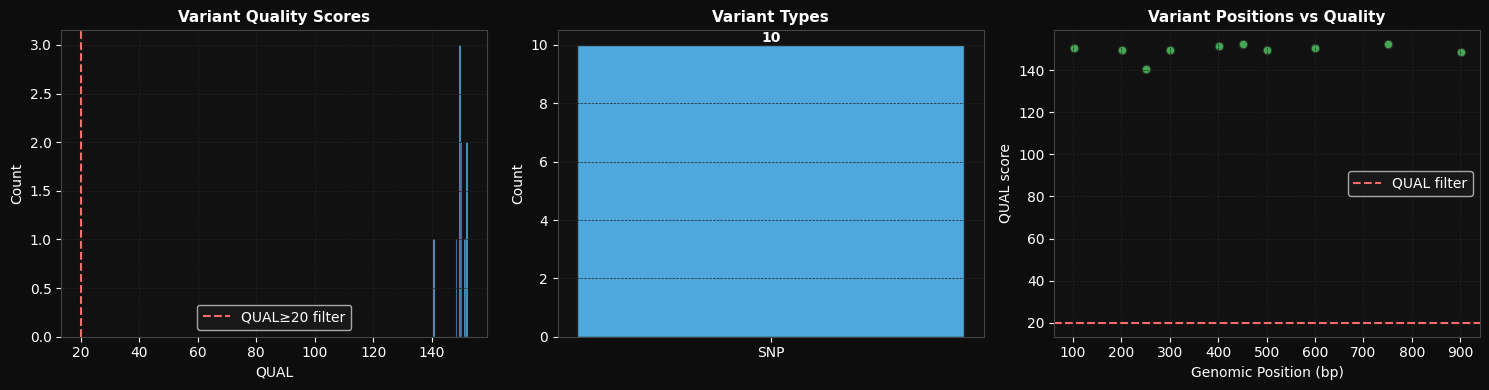

Saved: variant_calling_plots.png


In [32]:
# Parse and visualize variant calling results directly from VCF
import matplotlib.pyplot as plt
import numpy as np

quals, types, depths, positions = [], [], [], []

with open('filtered_variants.vcf') as f:
    for line in f:
        if line.startswith('#'):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 8:
            continue
        try:
            pos  = int(parts[1])
            ref  = parts[3]
            alt  = parts[4]
            qual = float(parts[5]) if parts[5] != '.' else 0
            filt = parts[6]

            # Variant type
            if len(ref) == 1 and len(alt) == 1:
                vtype = 'SNP'
            elif len(ref) > len(alt):
                vtype = 'DEL'
            else:
                vtype = 'INS'

            # DP from FORMAT field
            fmt_keys = parts[8].split(':')
            fmt_vals = parts[9].split(':')
            fmt = dict(zip(fmt_keys, fmt_vals))
            dp = int(fmt.get('DP', 0))

            quals.append(qual)
            types.append(vtype)
            depths.append(dp)
            positions.append(pos)
        except:
            continue

print(f"Total variants parsed: {len(quals)}")
print(f"SNPs:   {types.count('SNP')}")
print(f"INDELs: {types.count('INS') + types.count('DEL')}")
if types.count('SNP') > 0:
    ts = sum(1 for i,t in enumerate(types) if t=='SNP' and quals[i] > 0)
    print(f"Mean QUAL: {np.mean(quals):.1f}")
    print(f"Mean DP:   {np.mean(depths):.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#0d0d0d')

# QUAL distribution
ax = axes[0]
ax.set_facecolor('#111')
if quals:
    ax.hist(quals, bins=20, color='#4ea8de', edgecolor='#222', linewidth=0.3)
ax.axvline(20, color='#ff6b6b', linestyle='--', linewidth=1.5, label='QUAL≥20 filter')
ax.set_title('Variant Quality Scores', color='white', fontweight='bold', fontsize=11)
ax.set_xlabel('QUAL', color='white')
ax.set_ylabel('Count', color='white')
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_color('#444')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.grid(True, color='#222', linewidth=0.5, linestyle='--')

# Variant types
ax2 = axes[1]
ax2.set_facecolor('#111')
type_counts = {t: types.count(t) for t in ['SNP','INS','DEL'] if types.count(t) > 0}
colors_t = ['#4ea8de','#51cf66','#ff6b6b']
if type_counts:
    bars = ax2.bar(list(type_counts.keys()), list(type_counts.values()),
                   color=colors_t[:len(type_counts)], edgecolor='#222')
    for bar, val in zip(bars, type_counts.values()):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 str(val), ha='center', color='white', fontweight='bold')
ax2.set_title('Variant Types', color='white', fontweight='bold', fontsize=11)
ax2.set_ylabel('Count', color='white')
ax2.tick_params(colors='white')
for s in ax2.spines.values(): s.set_color('#444')
ax2.grid(True, axis='y', color='#222', linewidth=0.5, linestyle='--')

# Genomic position
ax3 = axes[2]
ax3.set_facecolor('#111')
if positions:
    ax3.scatter(positions, quals, color='#51cf66', s=40, alpha=0.8, edgecolor='#222')
ax3.axhline(20, color='#ff6b6b', linestyle='--', linewidth=1.5, label='QUAL filter')
ax3.set_title('Variant Positions vs Quality', color='white',
              fontweight='bold', fontsize=11)
ax3.set_xlabel('Genomic Position (bp)', color='white')
ax3.set_ylabel('QUAL score', color='white')
ax3.tick_params(colors='white')
for s in ax3.spines.values(): s.set_color('#444')
ax3.legend(facecolor='#1a1a1a', labelcolor='white')
ax3.grid(True, color='#222', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('variant_calling_plots.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print("Saved: variant_calling_plots.png")

In [33]:
from google.colab import files
for f in ['gwas_plots.png', 'pca_plots.png',
          'prs_plots.png', 'variant_calling_plots.png']:
    try:
        files.download(f)
        print(f"Downloaded: {f}")
    except:
        print(f"Missing: {f}")

Missing: gwas_plots.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: pca_plots.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: prs_plots.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: variant_calling_plots.png
